In [1]:
# Thiranex Data Science Internship
# Task 2: Predictive Modeling Using Machine Learning
# Project: Employee Attrition Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create an original synthetic employee attrition dataset

np.random.seed(42)

n = 100

data = {
    "Age": np.random.randint(22, 56, n),
    "Monthly_Income": np.random.randint(20000, 100000, n),
    "Job_Satisfaction": np.random.randint(1, 6, n),
    "Years_at_Company": np.random.randint(1, 16, n),
    "Overtime": np.random.choice(["Yes", "No"], n),
    "Work_Life_Balance": np.random.randint(1, 5, n),
    "Job_Level": np.random.randint(1, 5, n)
}

df = pd.DataFrame(data)

# Create the Attrition target based on employee characteristics
attrition_probability = (
    0.10
    + 0.20 * (df["Overtime"] == "Yes")
    + 0.15 * (df["Job_Satisfaction"] <= 2)
    + 0.10 * (df["Work_Life_Balance"] <= 2)
    + 0.10 * (df["Years_at_Company"] <= 2)
)

attrition_probability = np.clip(attrition_probability, 0, 0.85)

df["Attrition"] = np.random.binomial(1, attrition_probability)

# Display the first 10 rows
df.head(10)

,Age,Monthly_Income,Job_Satisfaction,Years_at_Company,Overtime,Work_Life_Balance,Job_Level,Attrition
0,50,43419,2,3,Yes,4,3,1
1,36,70636,1,2,No,1,2,0
2,29,70015,4,9,Yes,2,1,0
3,42,74268,4,8,Yes,2,3,1
4,40,38141,1,13,No,2,3,0
5,44,91910,2,12,Yes,2,1,0
6,32,76044,1,10,Yes,2,3,0
7,32,87214,4,7,Yes,3,3,0
8,45,53827,5,9,No,1,2,0
9,45,75820,5,4,No,3,3,0


In [3]:
# Check the dataset structure and basic information

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
print(df["Attrition"].value_counts())

Dataset Shape: (100, 8)

Missing Values:
Age                  0
Monthly_Income       0
Job_Satisfaction     0
Years_at_Company     0
Overtime             0
Work_Life_Balance    0
Job_Level            0
Attrition            0
dtype: int64

Duplicate Rows: 0

Target Distribution:
Attrition
0    56
1    44
Name: count, dtype: int64


In [4]:
# Convert categorical data into numerical form

df["Overtime"] = df["Overtime"].map({"No": 0, "Yes": 1})

# Separate features (X) and target (y)

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Age  Monthly_Income  Job_Satisfaction  Years_at_Company  Overtime  \
0   50           43419                 2                 3         1   
1   36           70636                 1                 2         0   
2   29           70015                 4                 9         1   
3   42           74268                 4                 8         1   
4   40           38141                 1                13         0   

   Work_Life_Balance  Job_Level  
0                  4          3  
1                  1          2  
2                  2          1  
3                  2          3  
4                  2          3  

Target:
0    1
1    0
2    0
3    1
4    0
Name: Attrition, dtype: int32


In [5]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (80, 7)
Testing data: (20, 7)
Training target: (80,)
Testing target: (20,)


In [6]:
# Train a Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [7]:
# Make predictions on the test data

y_pred = model.predict(X_test)

# Get prediction probabilities for ROC curve
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted Classes:")
print(y_pred)

print("\nPrediction Probabilities:")
print(y_prob)

Predicted Classes:
[0 1 0 1 0 0 0 1 0 0 0 1 1 0 1 1 0 0 0 1]

Prediction Probabilities:
[0.31 0.77 0.44 0.76 0.32 0.18 0.3  0.79 0.27 0.23 0.23 0.54 0.61 0.4
 0.58 0.66 0.13 0.47 0.21 0.56]


In [8]:
# Evaluate model performance

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-Score : {f1:.2f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Left"]
))

Model Performance
------------------
Accuracy : 0.75
Precision: 0.75
Recall   : 0.67
F1-Score : 0.71

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.75      0.82      0.78        11
        Left       0.75      0.67      0.71         9

    accuracy                           0.75        20
   macro avg       0.75      0.74      0.74        20
weighted avg       0.75      0.75      0.75        20



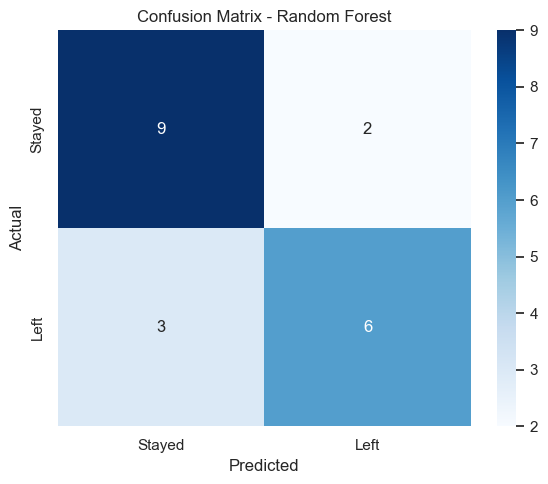

In [9]:
# Create and visualize the confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

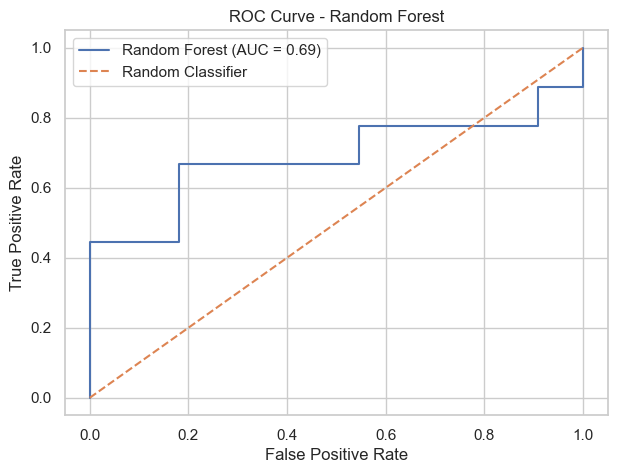

AUC Score: 0.69


In [10]:
# Create ROC Curve and calculate AUC

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score: {auc_score:.2f}")

In [11]:
# Analyze feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
             Feature  Importance
0                Age    0.237794
1     Monthly_Income    0.215527
3   Years_at_Company    0.192178
2   Job_Satisfaction    0.125382
6          Job_Level    0.096651
5  Work_Life_Balance    0.086918
4           Overtime    0.045550


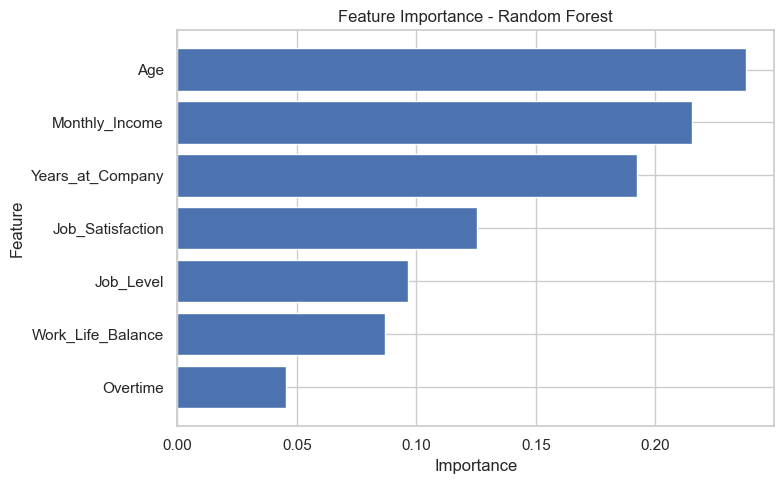

In [12]:
# Visualize feature importance

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [13]:
# Save the dataset for the project

df.to_csv("employee_attrition_data.csv", index=False)

print("Dataset saved successfully as employee_attrition_data.csv")

Dataset saved successfully as employee_attrition_data.csv


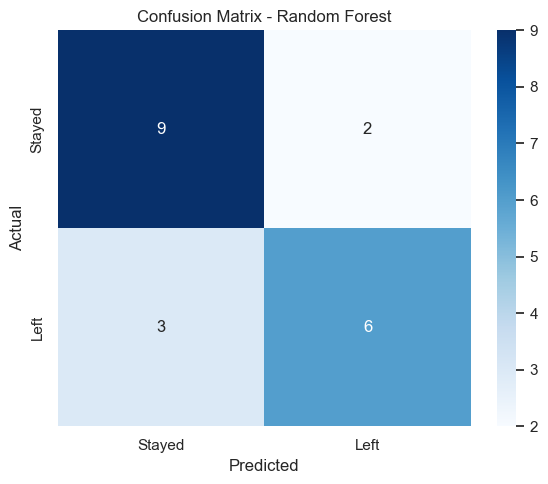

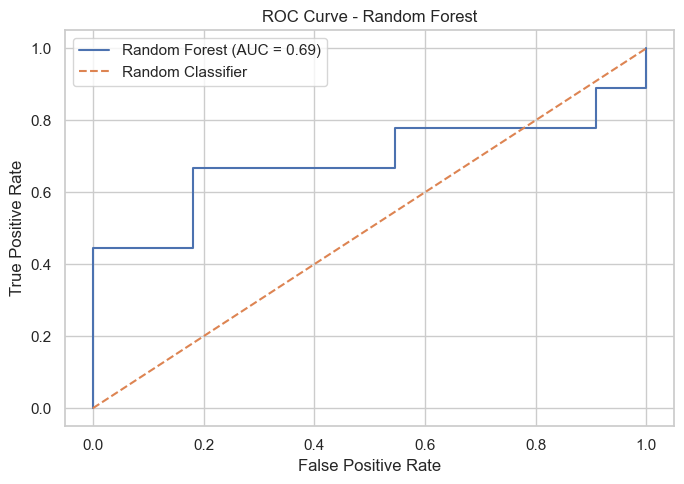

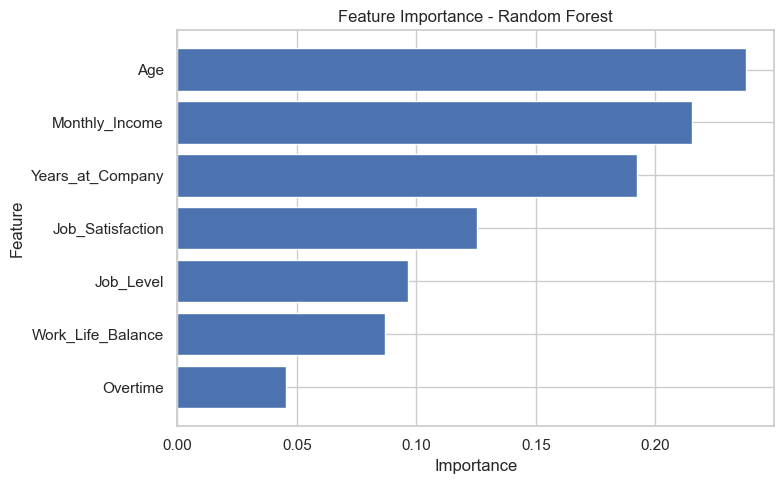

All visualizations saved successfully!


In [14]:
# Create folder for visualizations

import os

os.makedirs("visualizations", exist_ok=True)

# Save Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.savefig("visualizations/confusion_matrix.png", dpi=300)
plt.show()

# Save ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.2f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("visualizations/roc_curve.png", dpi=300)
plt.show()

# Save Feature Importance
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("visualizations/feature_importance.png", dpi=300)
plt.show()

print("All visualizations saved successfully!")

In [15]:
# Final Results and Conclusion

print("=" * 50)
print("EMPLOYEE ATTRITION PREDICTION - FINAL RESULTS")
print("=" * 50)

print(f"\nModel Used: Random Forest Classifier")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")

print("\nPerformance Metrics:")
print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1-Score : {f1:.2%}")
print(f"AUC      : {auc_score:.2f}")

print("\nTop 3 Important Features:")
for i, row in feature_importance.head(3).iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.3f}")

print("\nConclusion:")
print("The Random Forest model successfully predicts employee attrition")
print("using employee demographic, income, satisfaction, experience,")
print("overtime, work-life balance, and job-level information.")
print("The model achieved 75% accuracy on the test dataset.")

EMPLOYEE ATTRITION PREDICTION - FINAL RESULTS

Model Used: Random Forest Classifier
Training Samples: 80
Testing Samples: 20

Performance Metrics:
Accuracy : 75.00%
Precision: 75.00%
Recall   : 66.67%
F1-Score : 70.59%
AUC      : 0.69

Top 3 Important Features:
- Age: 0.238
- Monthly_Income: 0.216
- Years_at_Company: 0.192

Conclusion:
The Random Forest model successfully predicts employee attrition
using employee demographic, income, satisfaction, experience,
overtime, work-life balance, and job-level information.
The model achieved 75% accuracy on the test dataset.
